In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv(r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\unsupervised_machine_learning\datasets\Wholesale customers data.csv")

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None


In [5]:
features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = df[features]

In [7]:
X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


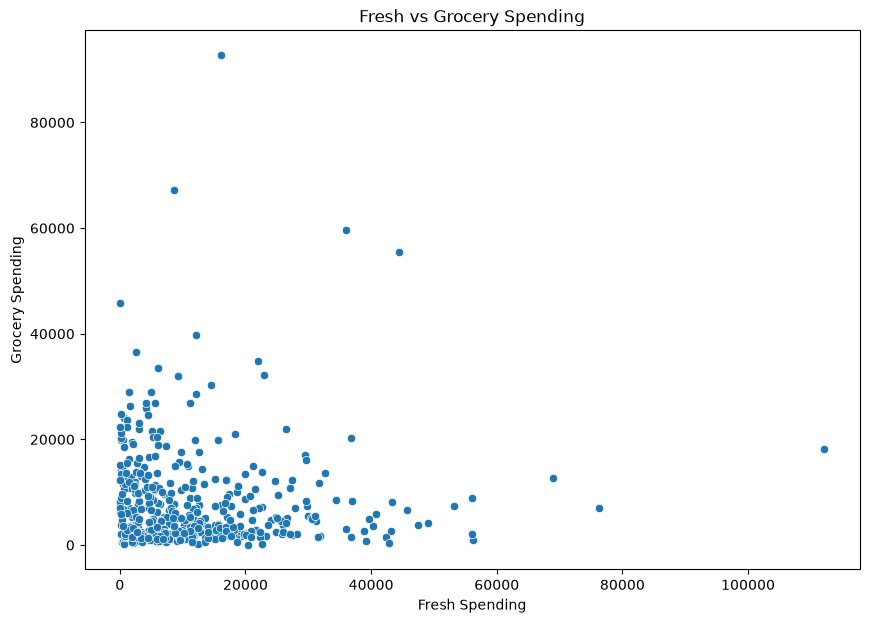

In [8]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Fresh",
    y="Grocery"
)

plt.title("Fresh vs Grocery Spending")

plt.xlabel("Fresh Spending")

plt.ylabel("Grocery Spending")

plt.show()

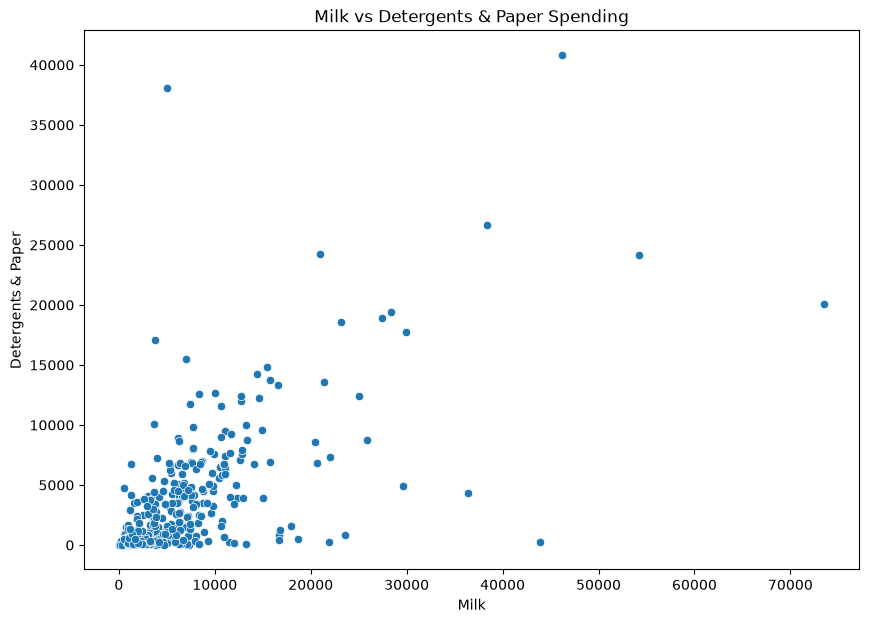

In [9]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Milk",
    y="Detergents_Paper"
)

plt.title(
    "Milk vs Detergents & Paper Spending"
)

plt.xlabel("Milk")

plt.ylabel("Detergents & Paper")

plt.show()

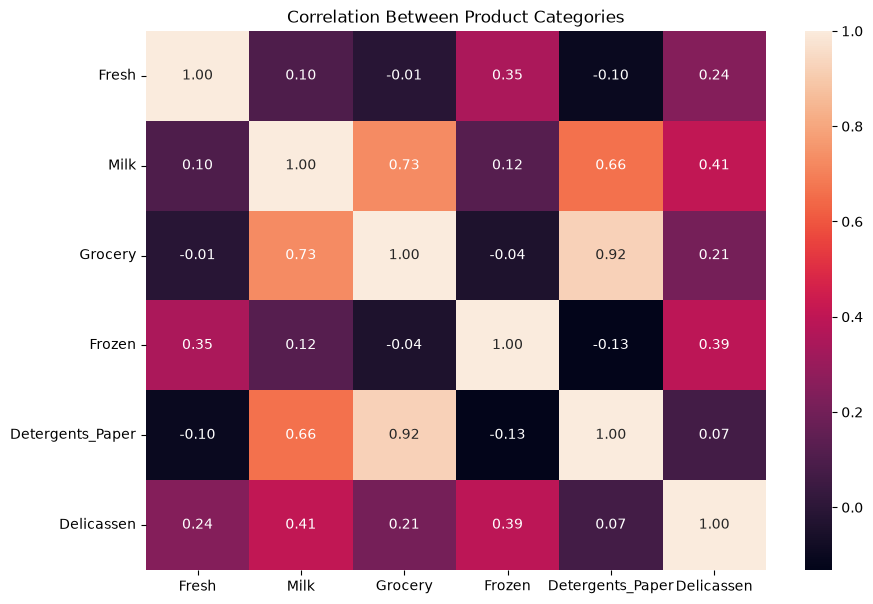

In [10]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f"
)

plt.title(
    "Correlation Between Product Categories"
)

plt.show()

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
print(X_scaled[:5])

[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822  0.09341105]
 [ 0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782  1.29934689]]


In [13]:
inertia = []
for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )

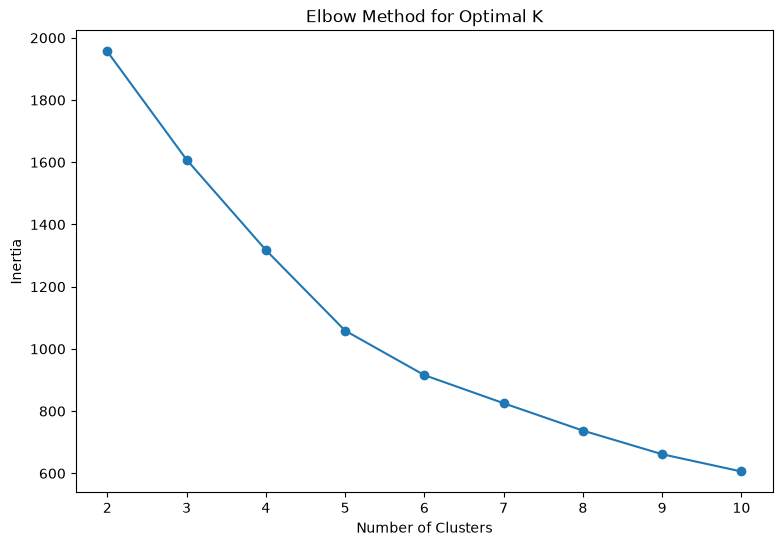

In [14]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method for Optimal K"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Inertia"
)

plt.show()

In [15]:
silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k} "
        f"| Silhouette Score = {score:.4f}"
    )

K = 2 | Silhouette Score = 0.5472
K = 3 | Silhouette Score = 0.5483
K = 4 | Silhouette Score = 0.3485
K = 5 | Silhouette Score = 0.3690
K = 6 | Silhouette Score = 0.3782
K = 7 | Silhouette Score = 0.3343
K = 8 | Silhouette Score = 0.3201
K = 9 | Silhouette Score = 0.3090
K = 10 | Silhouette Score = 0.3112


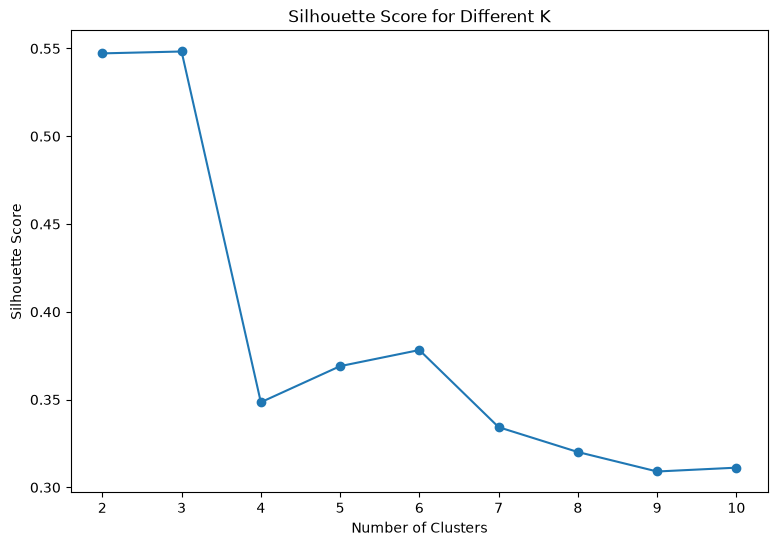

In [16]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title(
    "Silhouette Score for Different K"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Silhouette Score"
)

plt.show()

In [22]:
k=4
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
clusters=kmeans.fit_predict(
    X_scaled
)
df["Cluster"] = clusters

In [18]:
print(clusters)

[1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 1 3 0 1 1 1 0 1 1 1 1 1 1 0 1
 0 0 1 1 1 0 0 0 0 0 2 0 0 1 1 1 0 1 1 2 0 1 1 1 2 1 0 1 2 1 0 1 1 1 0 1 1
 1 1 1 0 1 1 1 0 0 1 1 2 2 3 1 1 1 1 2 1 0 1 1 1 1 1 0 0 0 1 1 1 0 0 0 0 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 3 0 3 1
 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 2 1 0 0 0 0 1 0 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 2 1 1 0 1 1 1 1
 1 1 1 1 1 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 3 1 1 1 1 1 0 1
 2 1 1 1 1 1 1 0 0 0 0 1 1 0 1 1 0 1 0 1 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1]


In [23]:
print(
    df["Cluster"].value_counts()
    .sort_index()
)

Cluster
0    110
1    315
2     10
3      5
Name: count, dtype: int64


In [24]:
cluster_profile = df.groupby(
    "Cluster"
)[features].mean()

print(cluster_profile)

                Fresh          Milk       Grocery        Frozen  \
Cluster                                                           
0         5591.436364  10113.027273  15637.390909   1499.918182   
1        13504.987302   3044.539683   3844.444444   3271.425397   
2        15964.900000  34708.500000  48536.900000   3054.600000   
3        50270.600000  26361.800000  16416.000000  25122.800000   

         Detergents_Paper    Delicassen  
Cluster                                  
0             6711.354545   1759.090909  
1              852.320635   1127.107937  
2            24875.200000   2942.800000  
3             2475.000000  18595.200000  


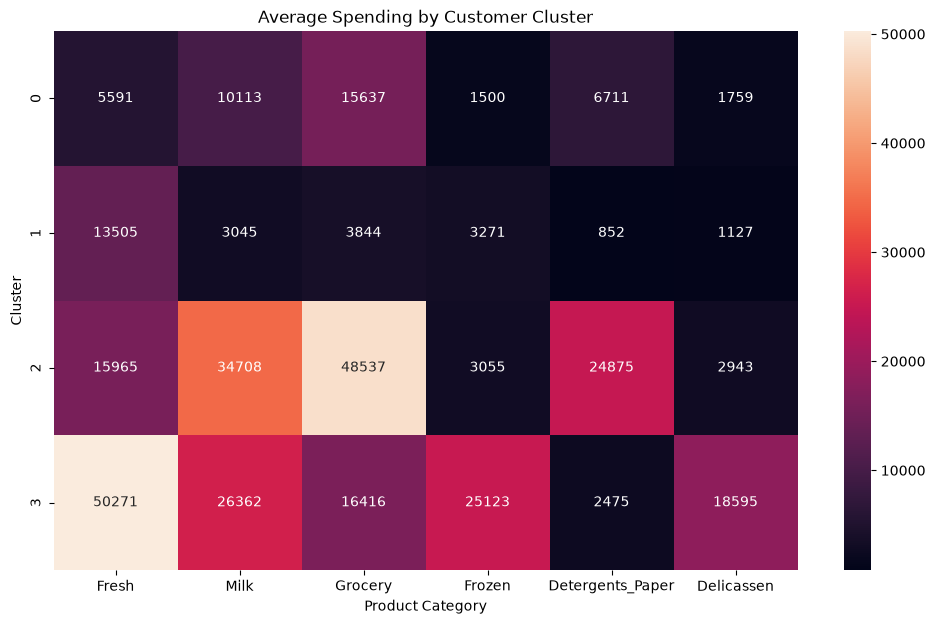

In [25]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".0f"
)

plt.title(
    "Average Spending by Customer Cluster"
)

plt.xlabel(
    "Product Category"
)

plt.ylabel(
    "Cluster"
)

plt.show()

In [27]:
profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(
        cluster_profile
    ),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

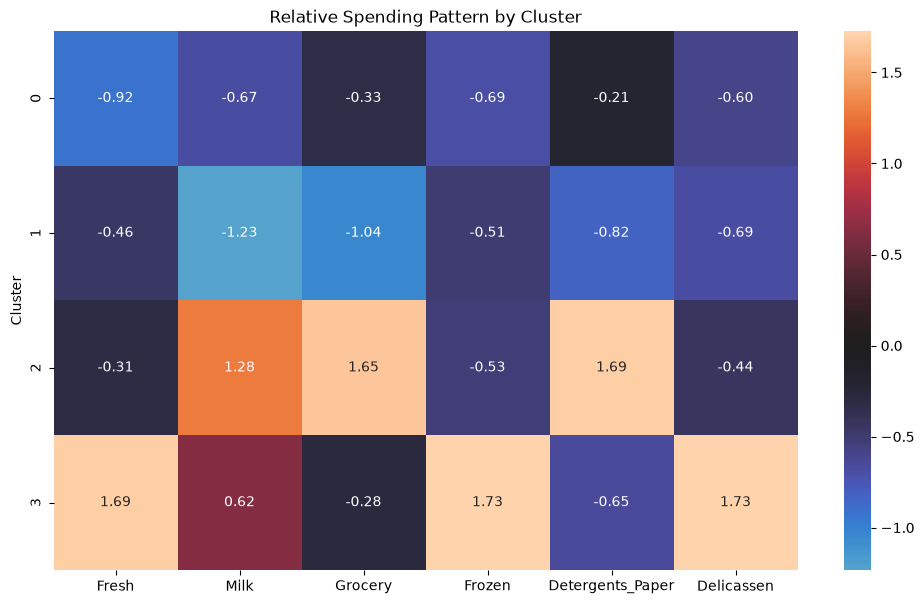

In [28]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    profile_scaled,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title(
    "Relative Spending Pattern by Cluster"
)

plt.show()

In [29]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

In [30]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

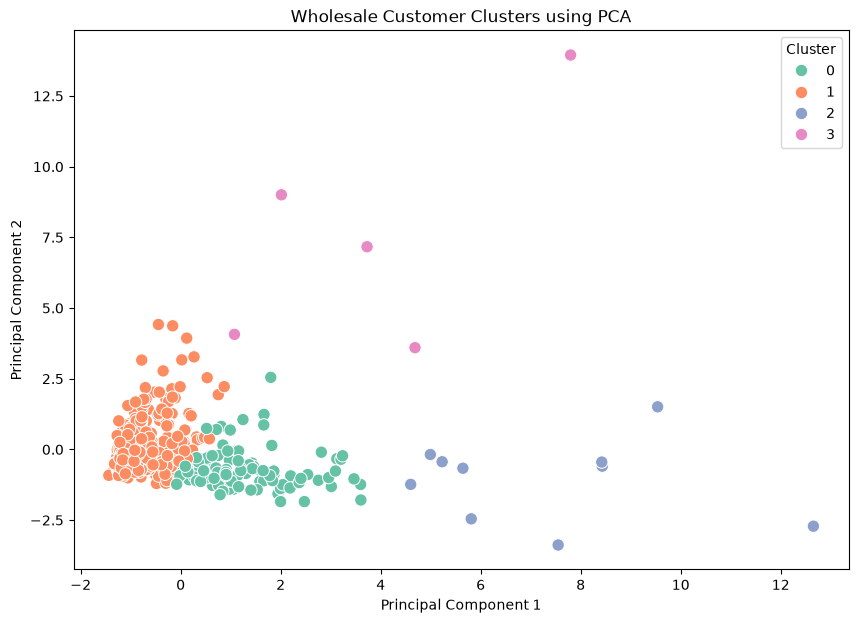

In [32]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title(
    "Wholesale Customer Clusters using PCA"
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [33]:
new_customer = pd.DataFrame({
    "Fresh": [15000],
    "Milk": [4000],
    "Grocery": [6000],
    "Frozen": [2500],
    "Detergents_Paper": [1000],
    "Delicassen": [800]
})

In [ ]:
scaler.fit_transform(new_customer)

In [34]:
new_customer_scaled = scaler.transform(
    new_customer
)

In [35]:
predicted_cluster = kmeans.predict(
    new_customer_scaled
)

In [36]:
print(
    "Predicted Cluster:",
    predicted_cluster[0]
)

Predicted Cluster: 1


In [37]:
cluster_id = predicted_cluster[0]

print(
    cluster_profile.loc[cluster_id]
)

Fresh               13504.987302
Milk                 3044.539683
Grocery              3844.444444
Frozen               3271.425397
Detergents_Paper      852.320635
Delicassen           1127.107937
Name: 1, dtype: float64


In [38]:
segment_names = {
    0: "Fresh/Frozen Focused",
    1: "Grocery & Detergents Focused",
    2: "Balanced Wholesale Customer",
    3: "High Milk/Grocery Customer"
}

In [39]:
predicted_segment = segment_names[
    predicted_cluster[0]
]

print(
    "Predicted Customer Segment:",
    predicted_segment
)


Predicted Customer Segment: Grocery & Detergents Focused


In [40]:
new_customer_pca = pca.transform(
    new_customer_scaled
)

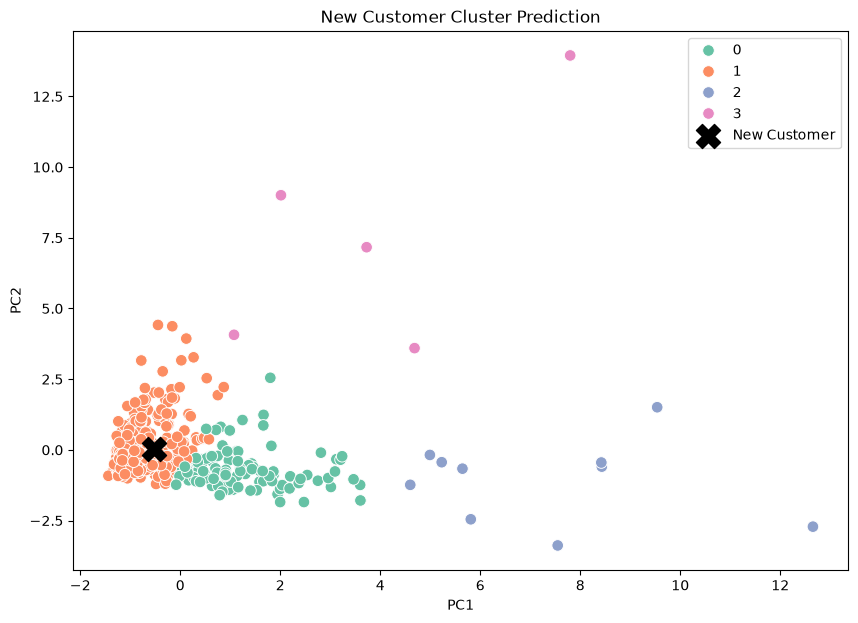

In [41]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.scatter(
    new_customer_pca[:, 0],
    new_customer_pca[:, 1],
    marker="X",
    s=300,
    color="black",
    label="New Customer"
)

plt.title(
    "New Customer Cluster Prediction"
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.legend()

plt.show()